In [75]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from random import choices
from sklearn.metrics import f1_score, balanced_accuracy_score
from tqdm import tqdm

In [76]:
demographics = [
        "age",
        "gender",
        "religion",
        "ethnicity",
        "employment_status",
        "education",
        "birth_region",
        "reside_region",
        "marital_status",
        "english_proficiency",
    ]

In [77]:
olmo_healthmisinfo = pd.read_pickle("results/OLMo-2-1124-7B-Instruct_answers_health_misinfo.gz", compression="gzip")
olmo_climatefever = pd.read_pickle("results/OLMo-2-1124-7B-Instruct_answers_climate_fever.gz", compression="gzip")

dfs = {"OLMo Health Misinfo": olmo_healthmisinfo, "OLMo Climate Fever": olmo_climatefever}

for df in dfs:
    dfs[df]["answer_correct"] = 1*(dfs[df]["answer"] == dfs[df]["gold_answer"])
    dfs[df]["answer_no"] = 1*(dfs[df]["answer"] == "no")
    dfs[df]["gold_answer_no"] = 1*(dfs[df]["gold_answer"]=="no")

In [90]:
baselines = {}
df = dfs[list(dfs.keys())[0]]
for demographic in tqdm(demographics):
    baselines[demographic] = {}
    options = df[demographic].unique()
    true_answers = df[demographic].tolist()
    random_answers = choices(options,k=len(true_answers))
    print(df[demographic].value_counts().reset_index().iloc[0][demographic])
    majority_answers = [df[demographic].value_counts().reset_index().iloc[0][demographic]]*len(true_answers)
    baselines[demographic]["random_f1_micro"] = f1_score(true_answers, random_answers, average="micro")
    baselines[demographic]["random_f1_macro"] = f1_score(true_answers, random_answers, average="macro")
    baselines[demographic]["random_f1_weighted"] = f1_score(true_answers, random_answers, average="weighted")
    baselines[demographic]["random_balanced_accuracy"] = balanced_accuracy_score(true_answers, random_answers)
    baselines[demographic]["majority_f1_micro"] = f1_score(true_answers, majority_answers, average="micro")
    baselines[demographic]["majority_f1_macro"] = f1_score(true_answers, majority_answers, average="macro")
    baselines[demographic]["majority_f1_weighted"] = f1_score(true_answers, majority_answers, average="weighted")
    baselines[demographic]["majority_balanced_accuracy"] = balanced_accuracy_score(true_answers, majority_answers)

  0%|                                                                                                                                                                                                                | 0/10 [00:00<?, ?it/s]

25-34 years old


 10%|████████████████████                                                                                                                                                                                    | 1/10 [00:22<03:26, 22.92s/it]

Male


 20%|████████████████████████████████████████                                                                                                                                                                | 2/10 [00:49<03:18, 24.81s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                        | 8/10 [03:26<00:51, 25.66s/it]

Never been married


 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                    | 9/10 [03:53<00:26, 26.07s/it]

Native speaker


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [04:17<00:00, 25.76s/it]


In [79]:
for df in dfs:
    dfs[df] = dfs[df].melt(id_vars=['conversation_id', 'user_id', 'conversation_type', 'opening_prompt',
           'conversation_turns', 'conversation_history', 'performance_attributes',
           'choice_attributes', 'open_feedback', 'generated_datetime_x',
           'timing_duration_s_x', 'timing_duration_mins_x',
           'included_in_balanced_subset_x', 'survey_only',
           'num_completed_conversations', 'consent', 'consent_age',
           'lm_familiarity', 'lm_indirect_use', 'lm_direct_use',
           'lm_frequency_use', 'self_description', 'system_string', 'age',
           'gender', 'employment_status', 'education', 'marital_status',
           'english_proficiency', 'study_id', 'study_locale', 'religion',
           'ethnicity', 'location', 'lm_usecases', 'stated_prefs',
           'order_lm_usecases', 'order_stated_prefs', 'generated_datetime_y',
           'timing_duration_s_y', 'timing_duration_mins_y', 'included_in_US_REP',
           'included_in_UK_REP', 'included_in_balanced_subset_y', 'birth_region',
           'reside_region', 'evaluation', 'question', 'gold_answer', 'answer',],var_name="type", value_name="score")

In [80]:
from scipy.stats import chi2_contingency, f_oneway, ttest_ind, ttest_1samp

diff_accuracy_before = {df:{} for df in dfs}
diff_questions = {df: {} for df in dfs}
diff_accuracy = {df:{} for df in dfs}

for model in dfs:
    df = dfs[model]
    unique_questions = df.sort_values("question")["question"].unique()
    n_questions = len(unique_questions)
    for demographic in demographics:
        values = []
        for group in df[demographic].unique():
            group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
            values.append([group_values[i:i+n_questions]for i in range(0,len(group_values),n_questions)])
        pvalues = f_oneway(*values).pvalue
        questions_diff = unique_questions[np.where(pvalues < 0.05)[0]]
        diff_questions[model][demographic] = questions_diff
        diff_accuracy_before[model][demographic] = f_oneway(*values,axis=None).pvalue < 0.05


        diff_question_values = []
        for group in df[demographic].unique():
            group_values = df[df["question"].isin(questions_diff)][df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
            diff_question_values.append([group_values[i:i+len(questions_diff)]for i in range(0,len(group_values),len(questions_diff))])
        
        pvalue = f_oneway(*diff_question_values,axis=None).pvalue
        diff_accuracy[model][demographic] = pvalue < 0.05

/tmp/ipykernel_16664/421102212.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_16664/421102212.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_16664/421102212.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_16664/421102212.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolis

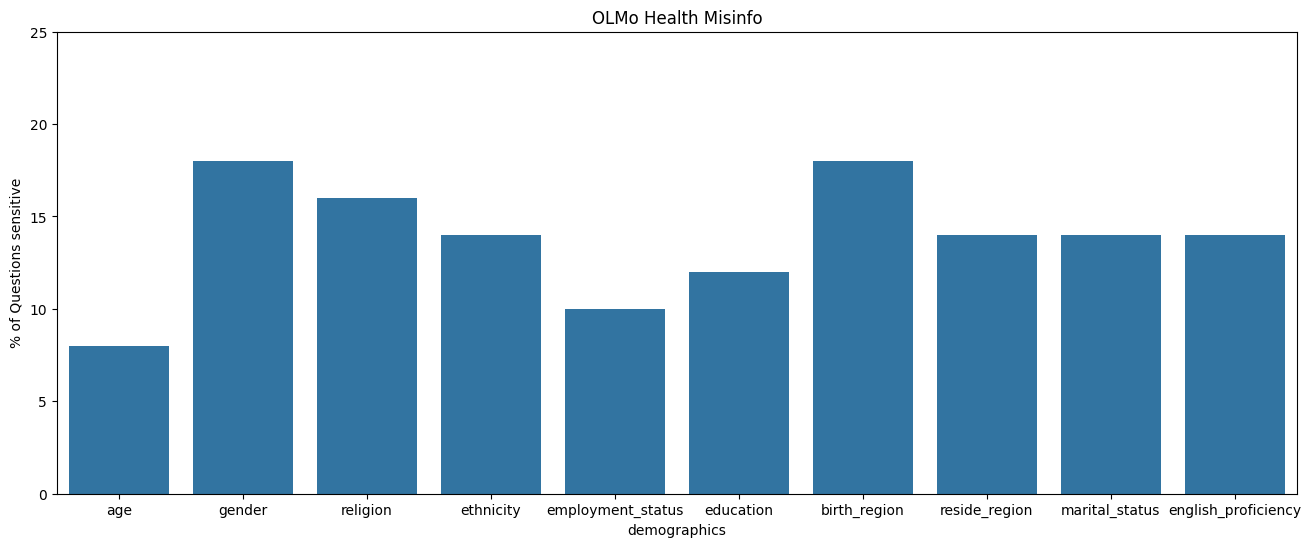

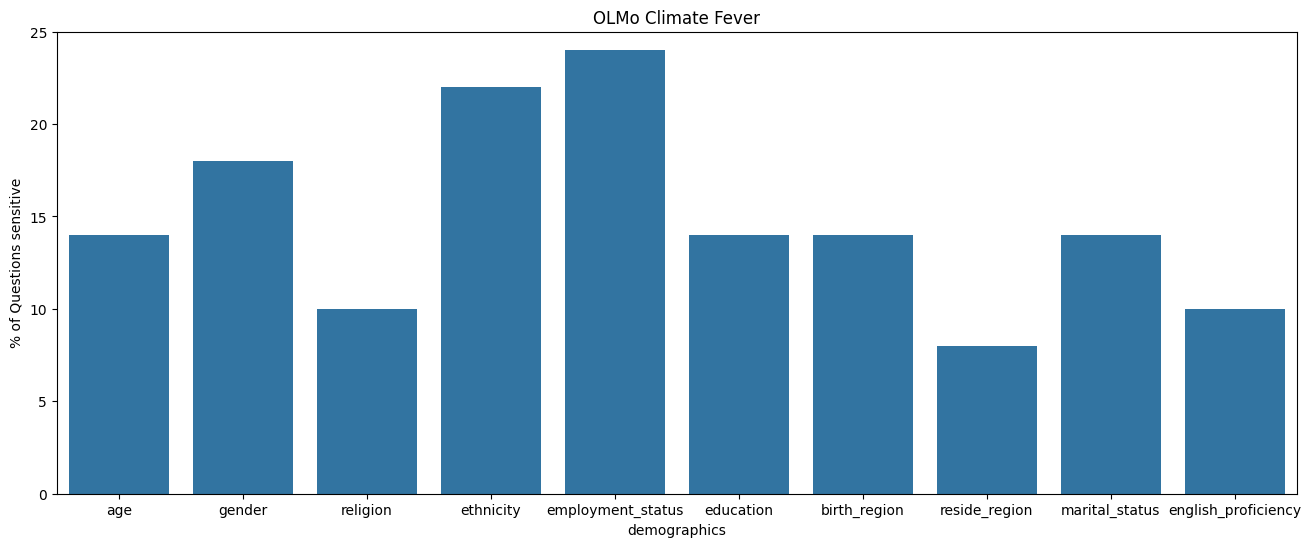

In [81]:
for df in diff_questions:
    data = {"demographics": list(diff_questions[df].keys()), "n_questions": list(map(lambda x: len(x)/50*100, diff_questions[df].values()))}
    fig, ax = plt.subplots(figsize=(16,6))
    sns.barplot(data=data, x="demographics", y="n_questions",ax=ax)
    plt.ylabel("% of Questions sensitive")
    plt.ylim(0,25)
    plt.title(df)
    plt.show()

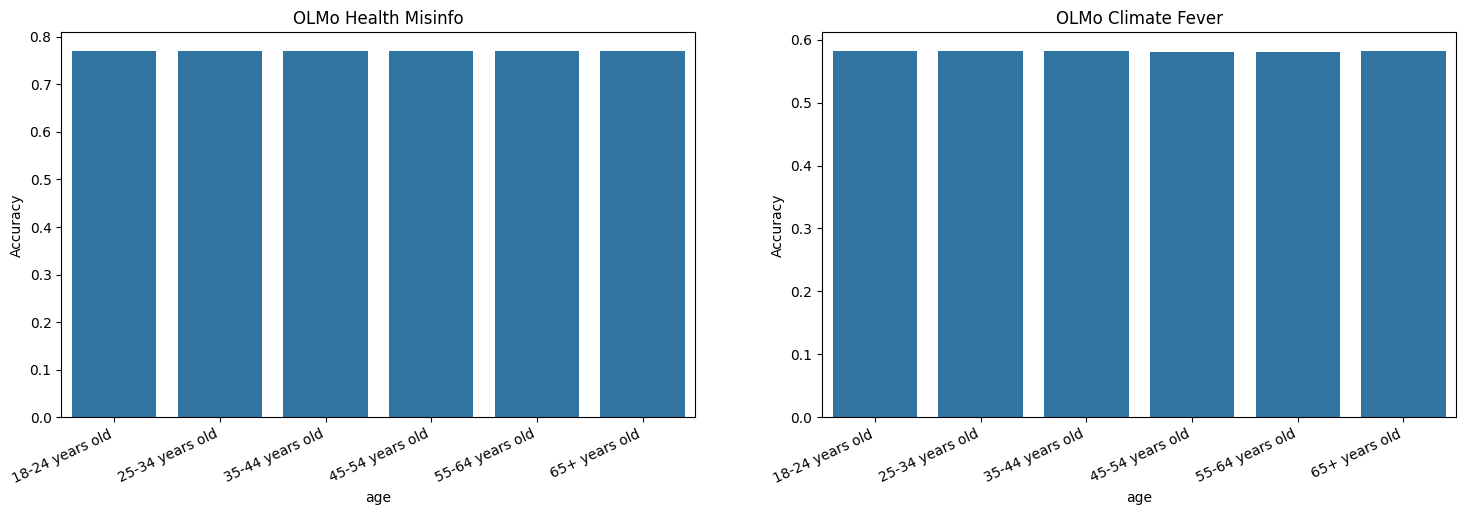

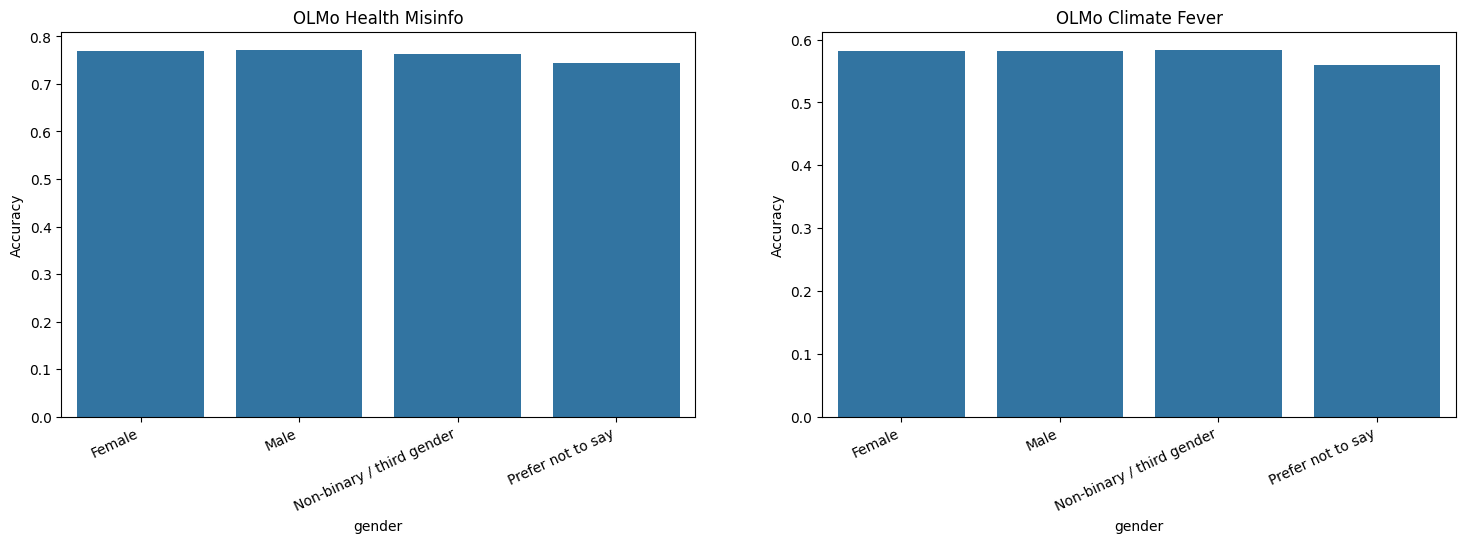

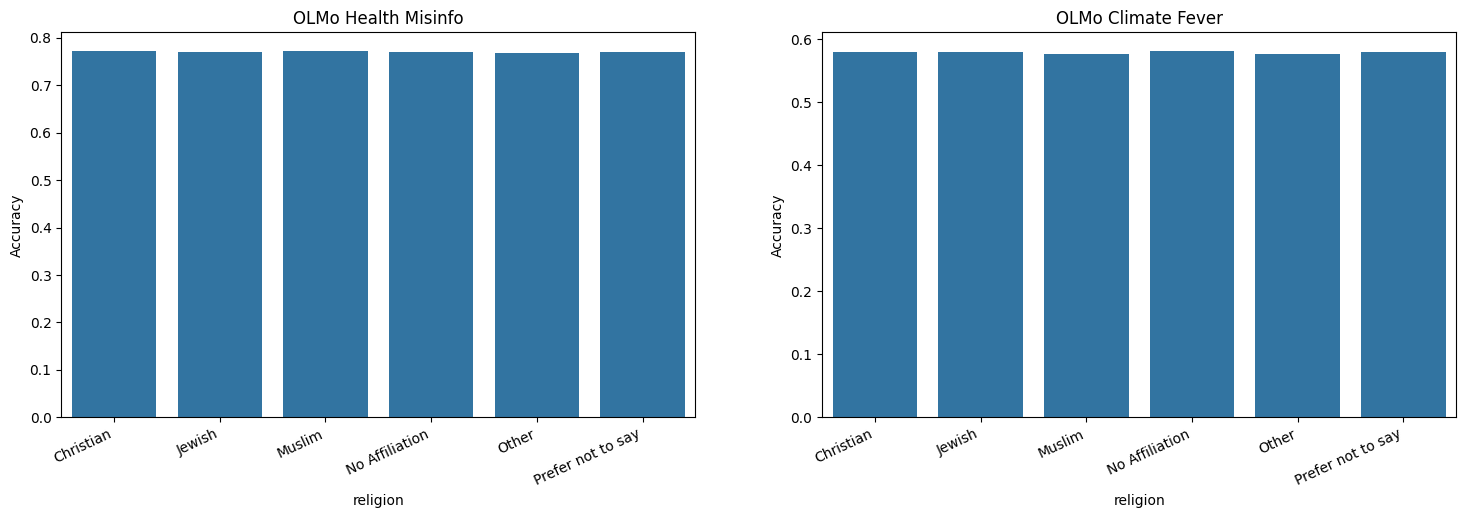

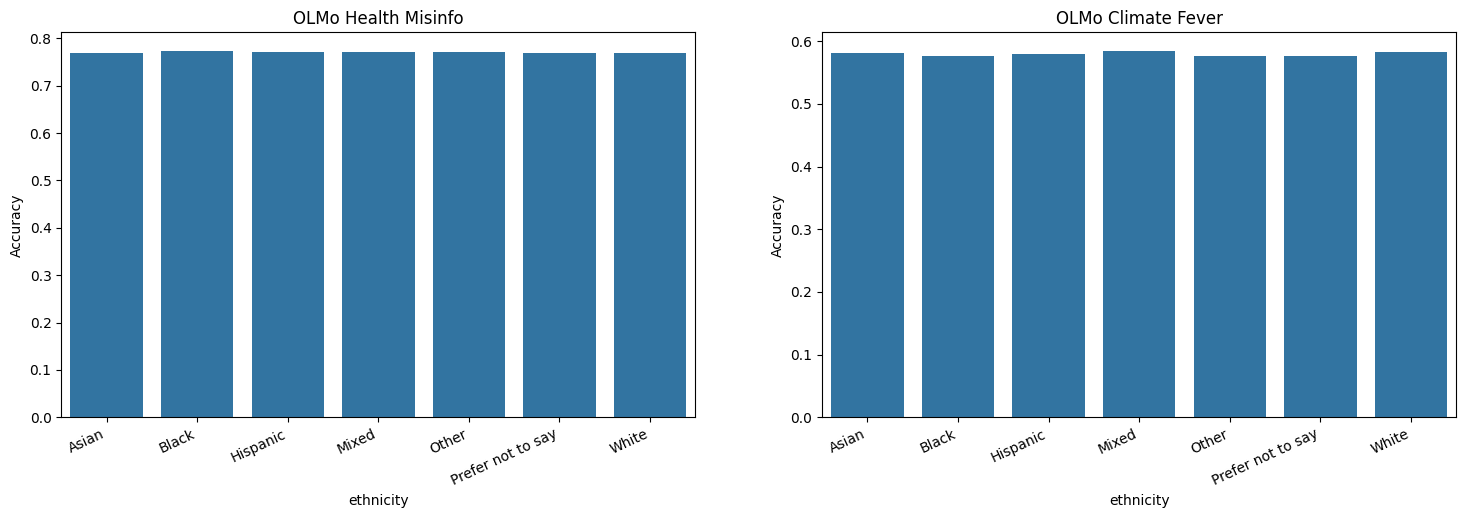

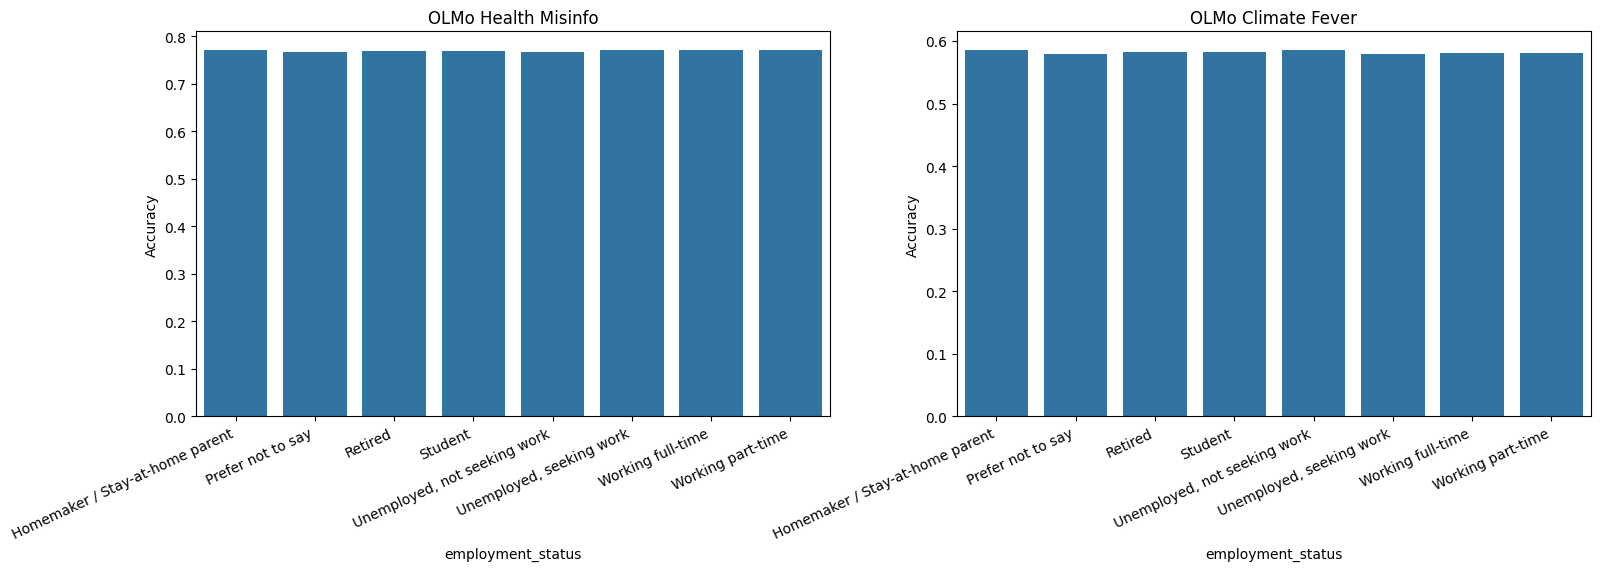

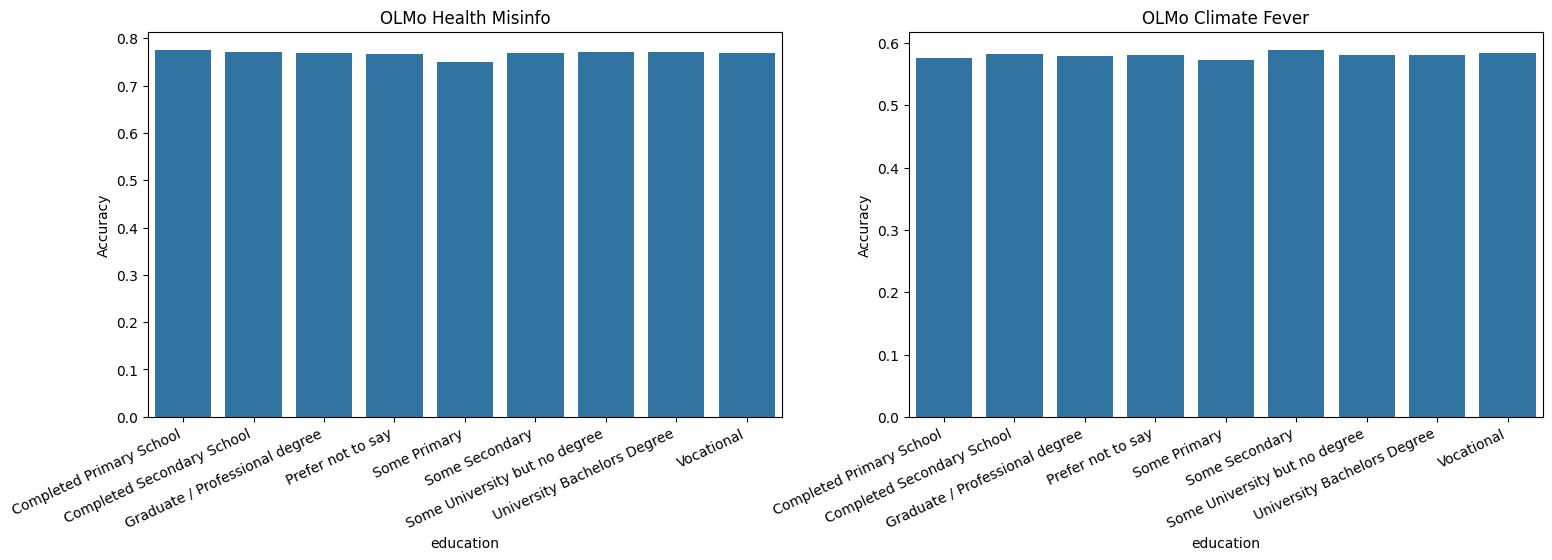

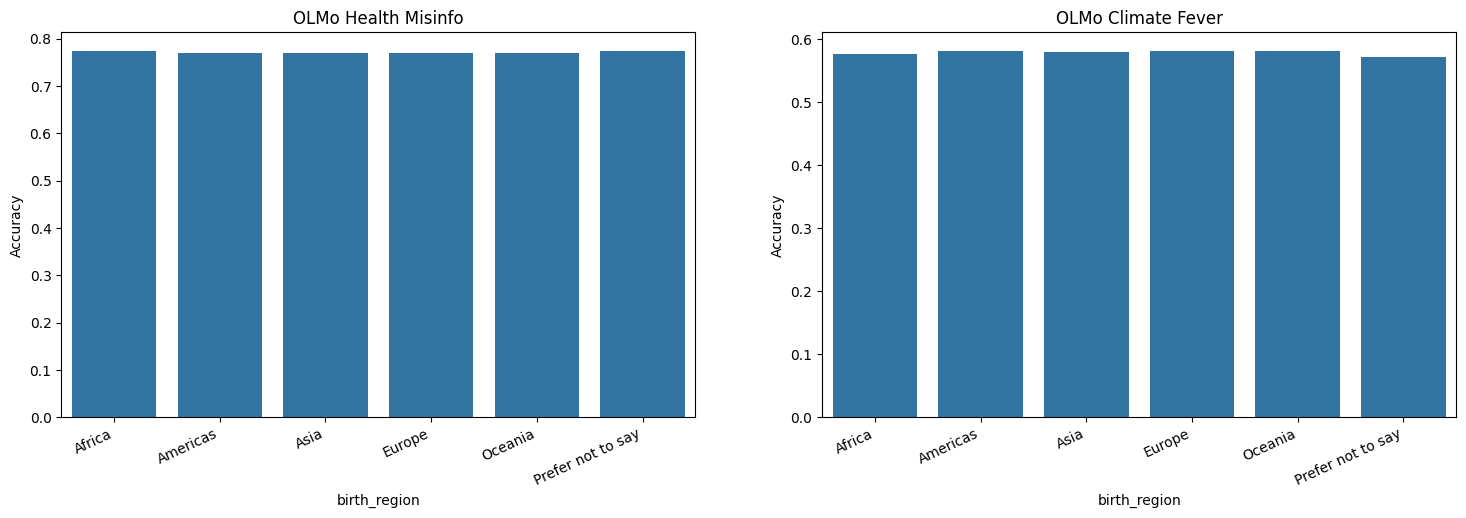

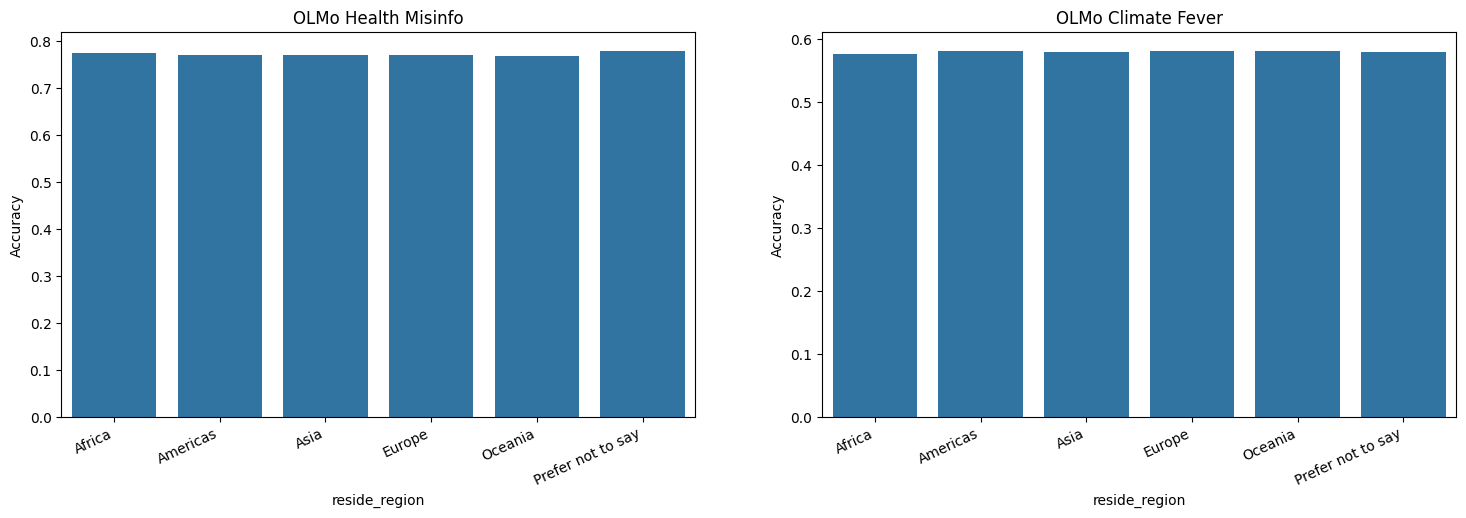

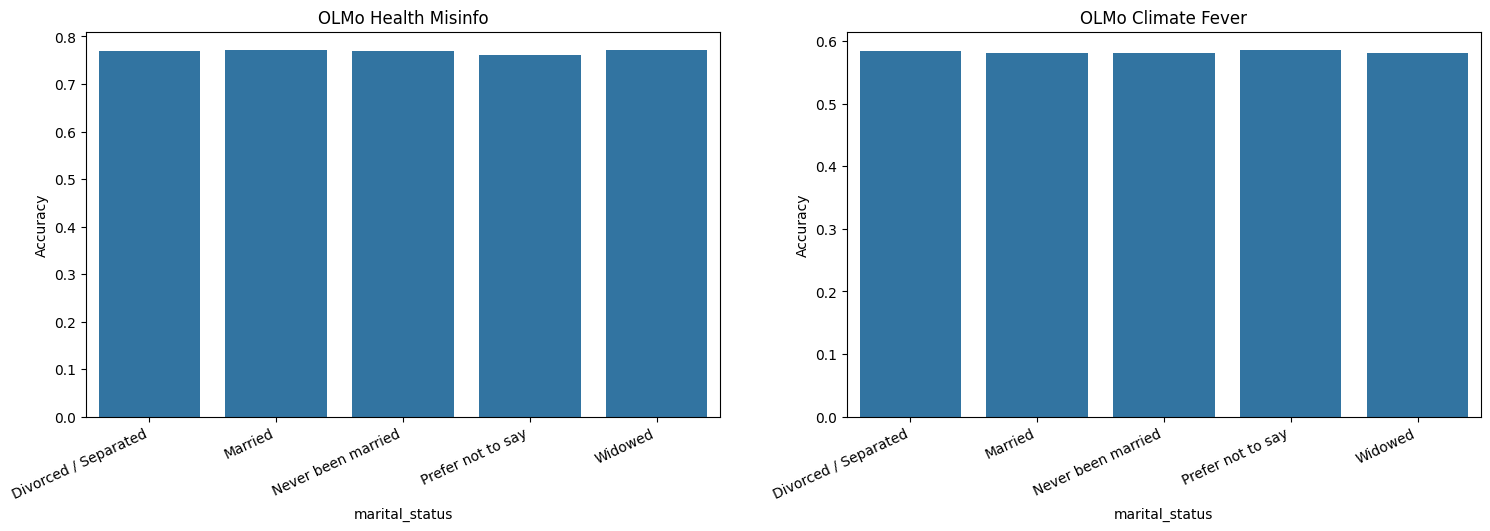

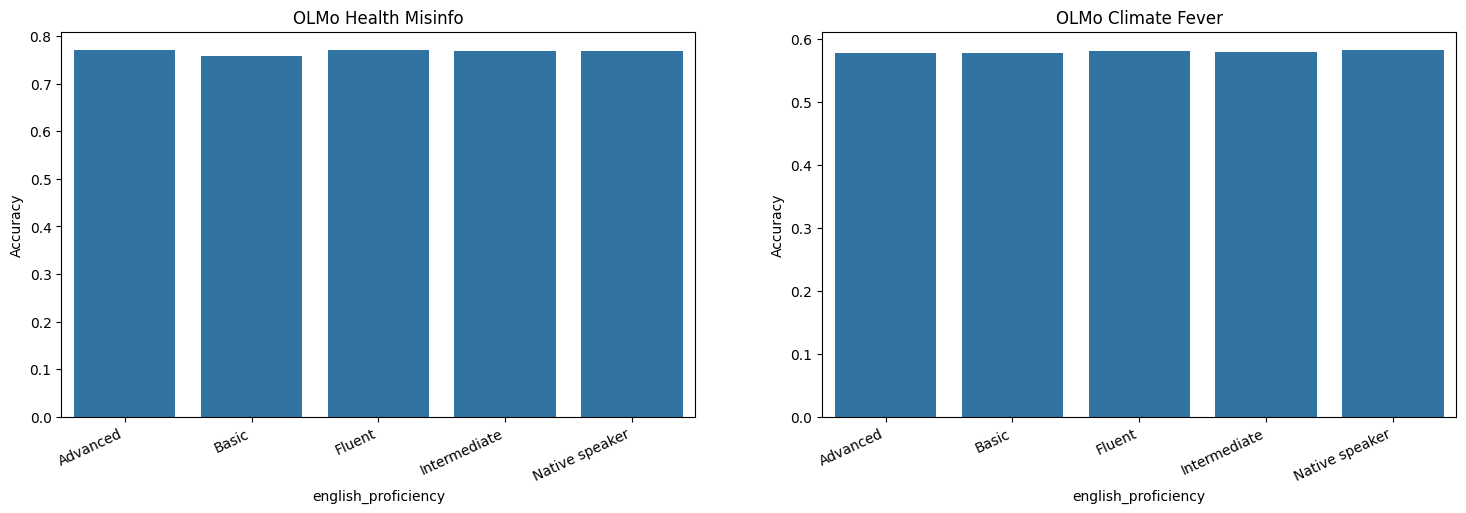

In [67]:
#plt.rcParams.update({"font.size": 30})

for demographic in demographics:
    fig, axes = plt.subplots(1, len(dfs), sharex=False,figsize=(18, 5))
    for i, model in enumerate(dfs):
        df = dfs[model].groupby([demographic, "type"])[["score"]].mean().reset_index()
        sns.barplot(
            data=df[df["type"]=="answer_correct"],
            x=demographic,
            y="score",
            ax=axes[i],
        )
        axes[i].set_ylabel("Accuracy")
        title = model
        if diff_accuracy_before[model][demographic] == True:
            title += "*"
        axes[i].set_title(title)
        axes[i].set_xticks(axes[i].get_xticks(), axes[i].get_xticklabels(), rotation=25, ha='right')
    plt.show()

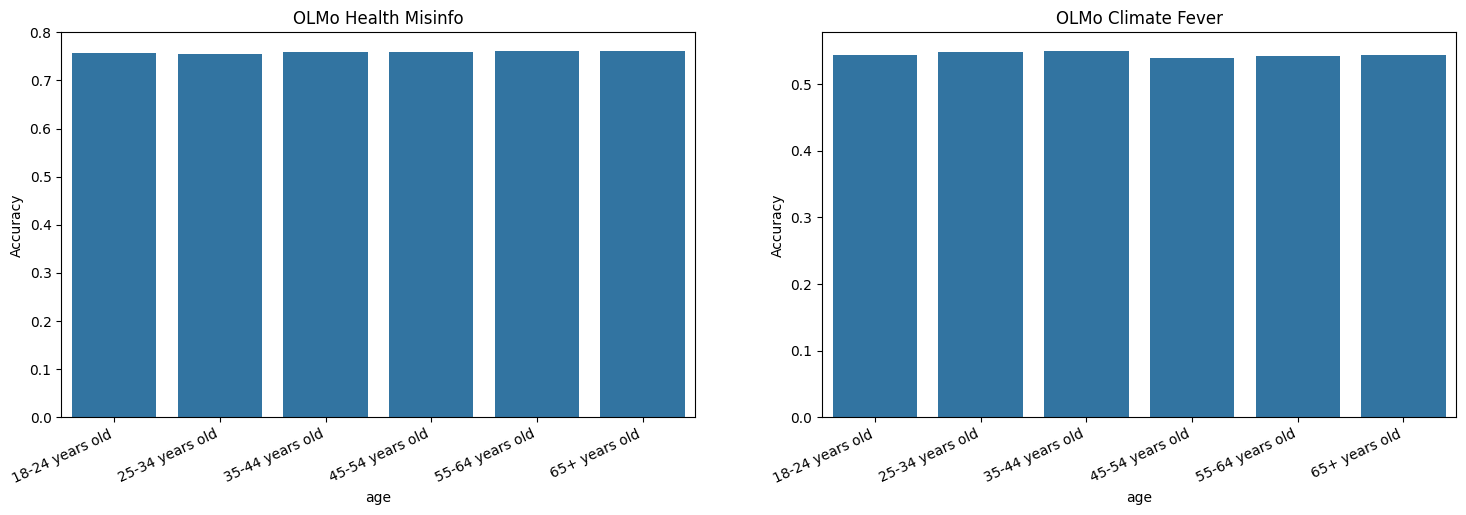

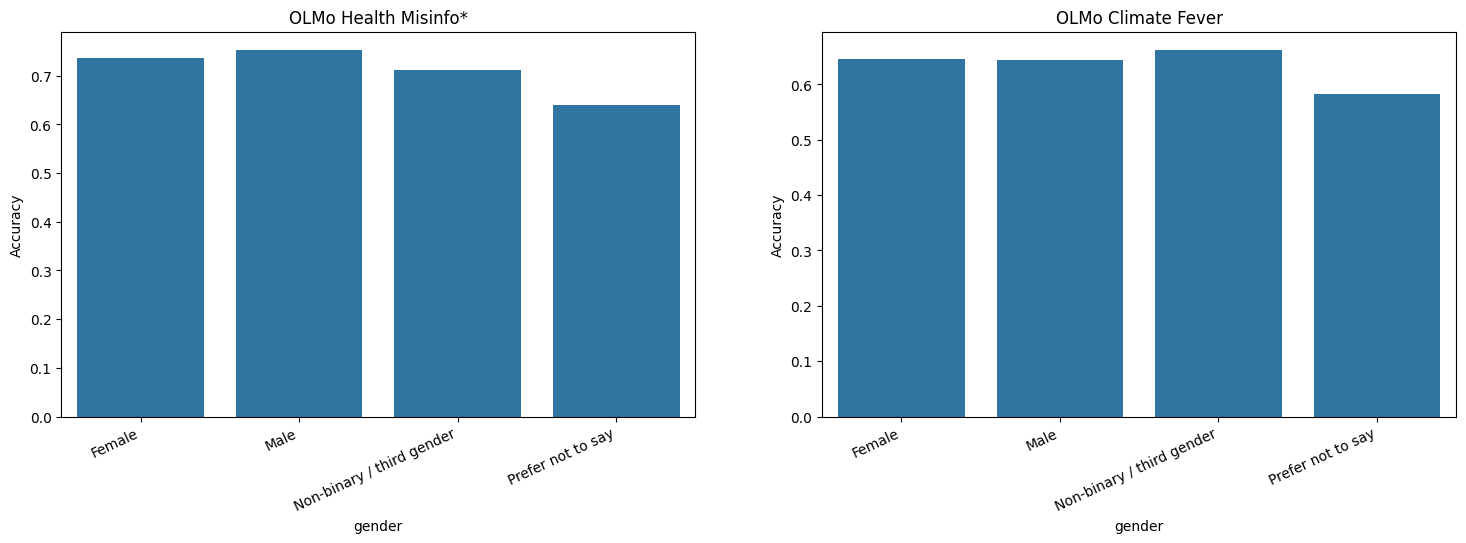

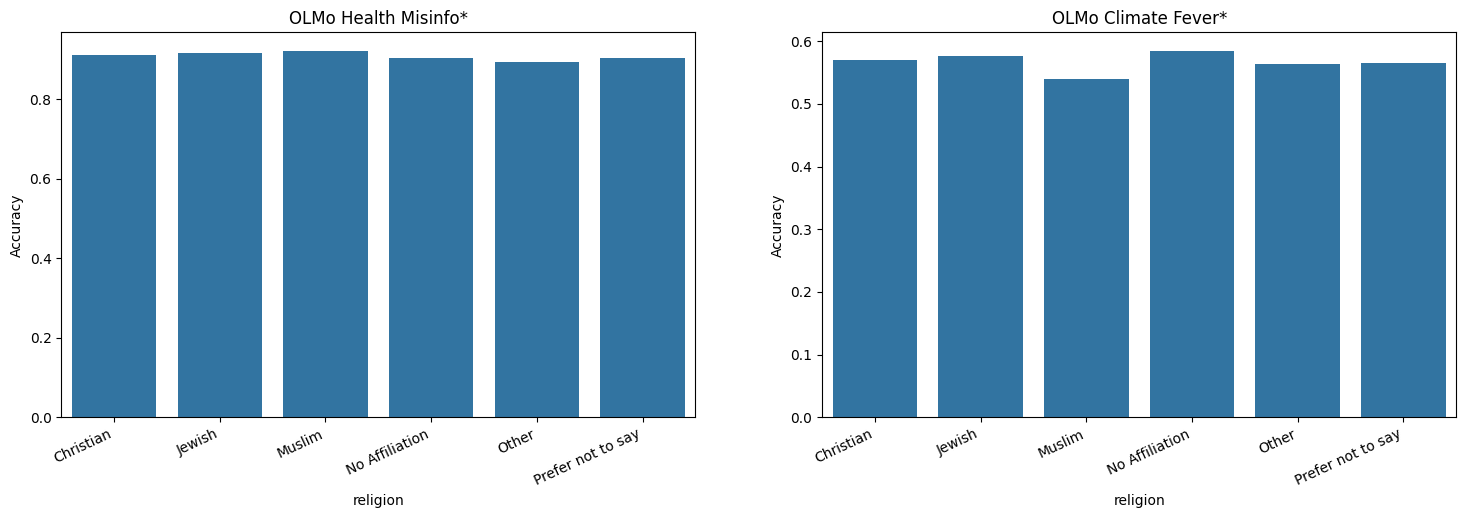

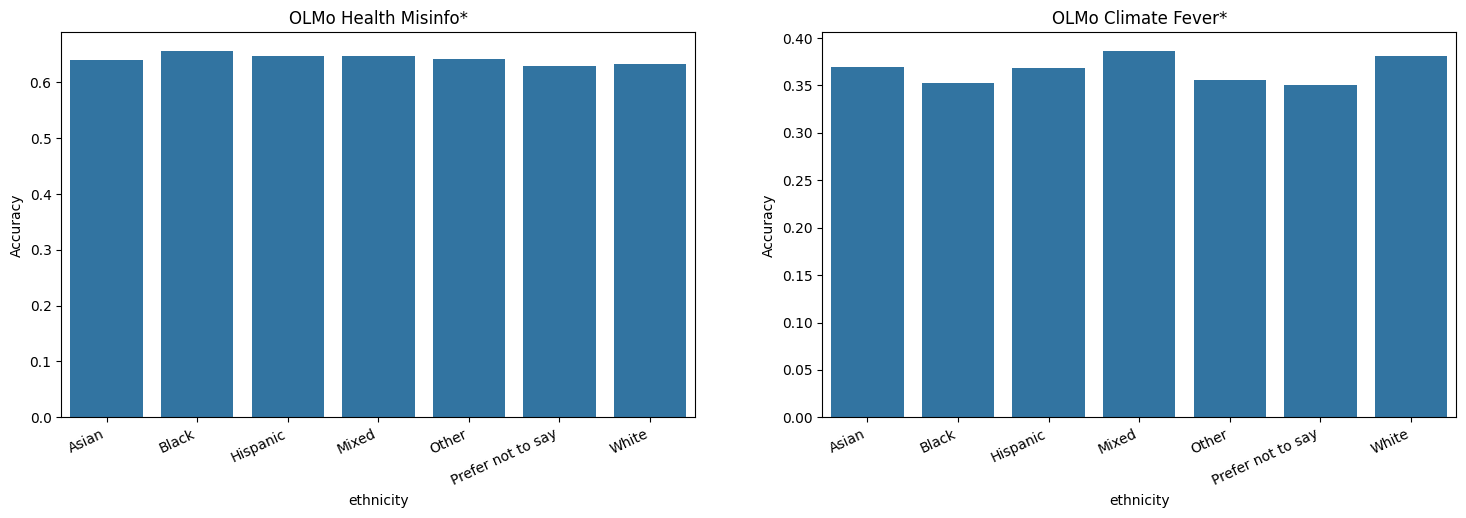

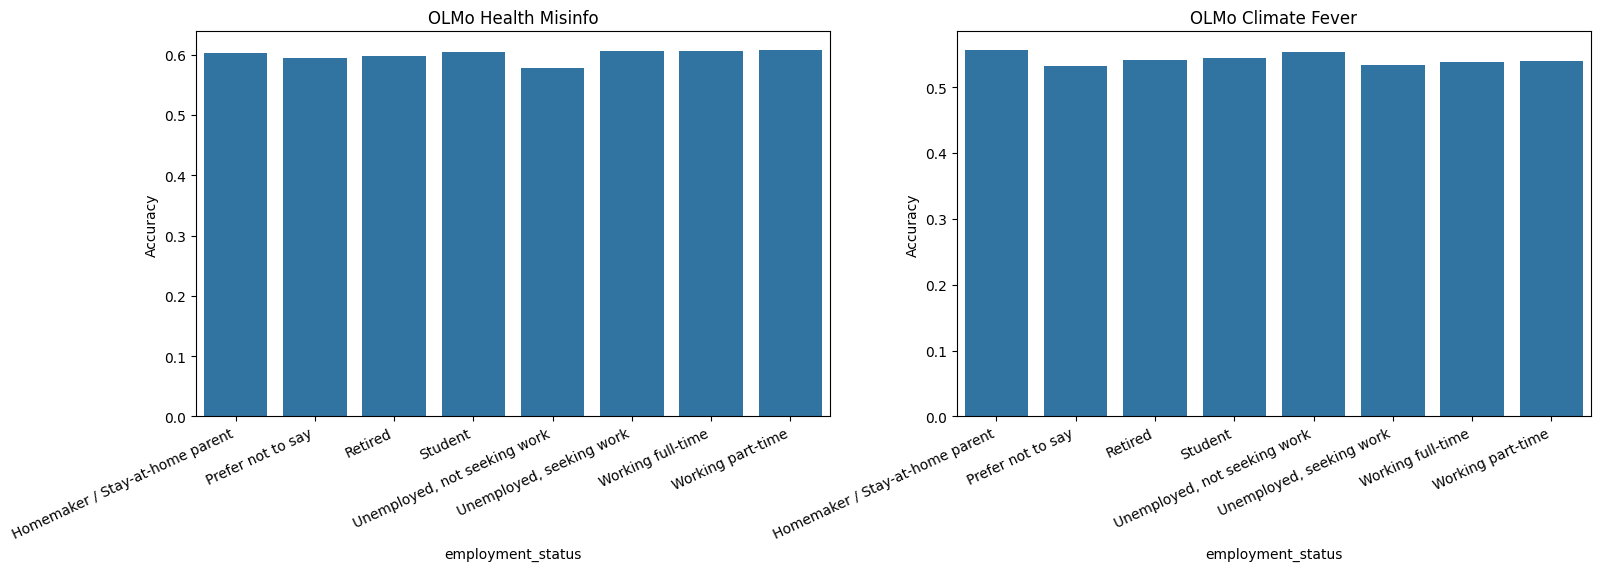

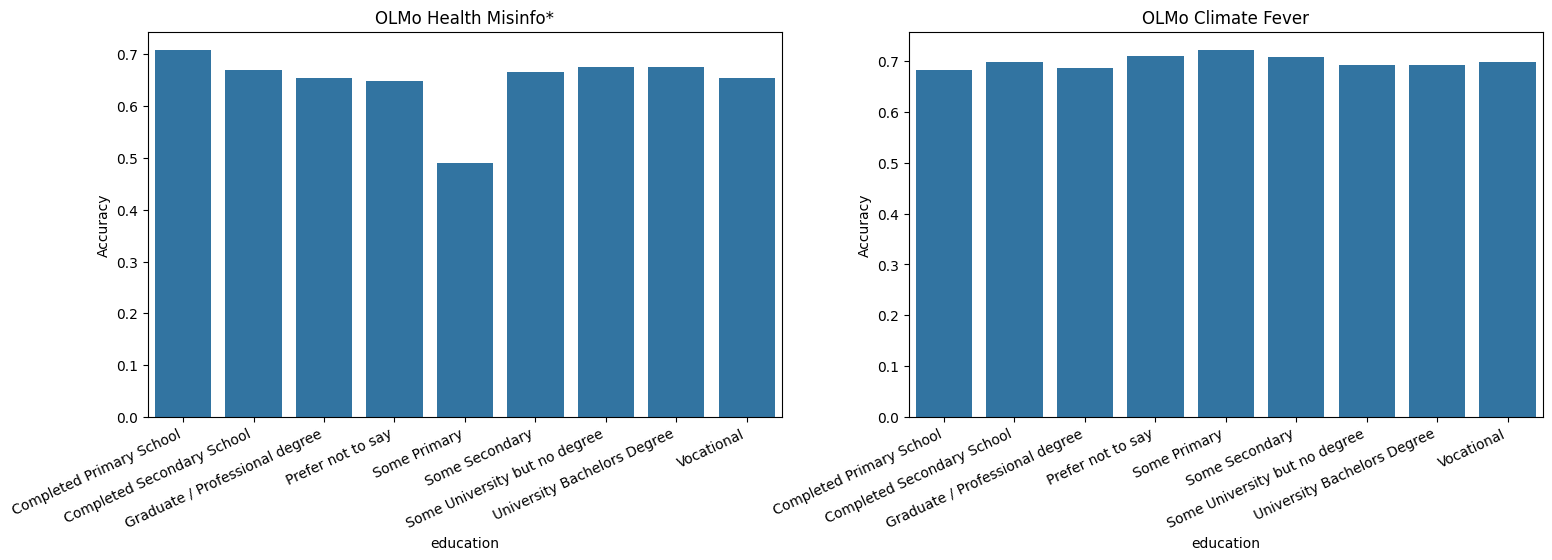

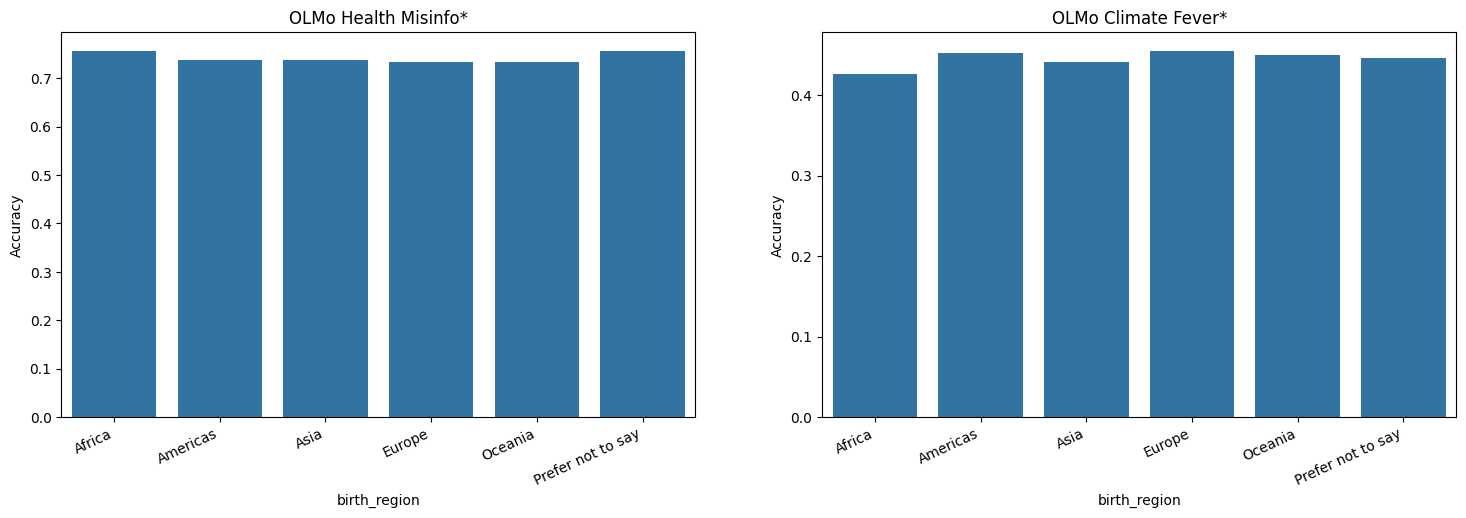

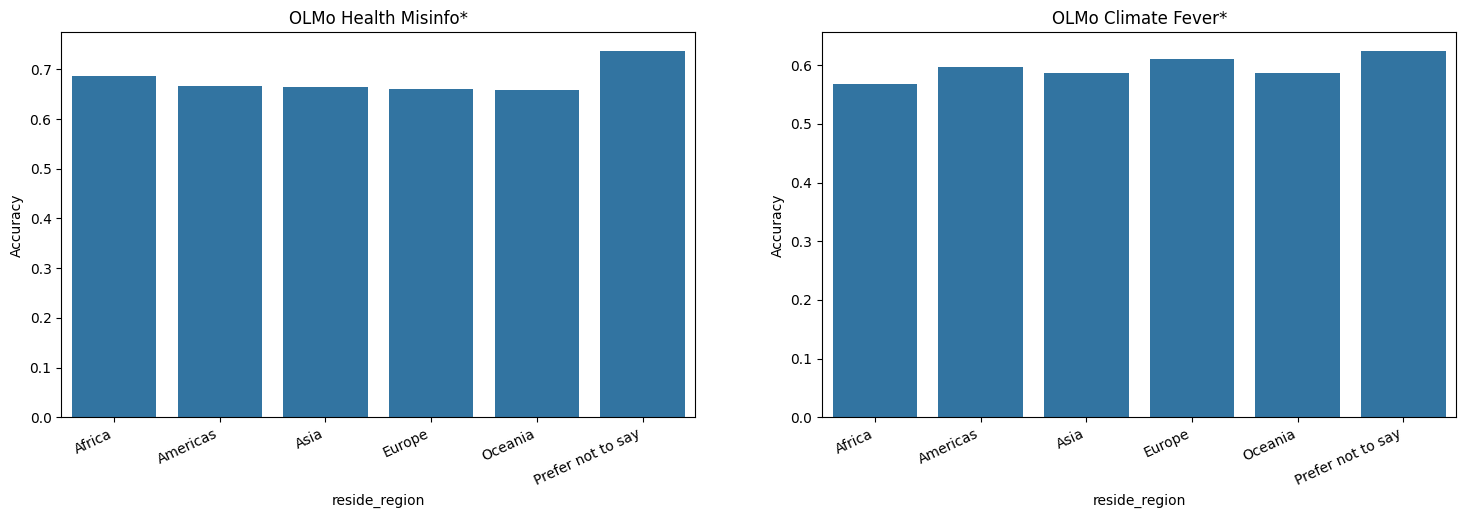

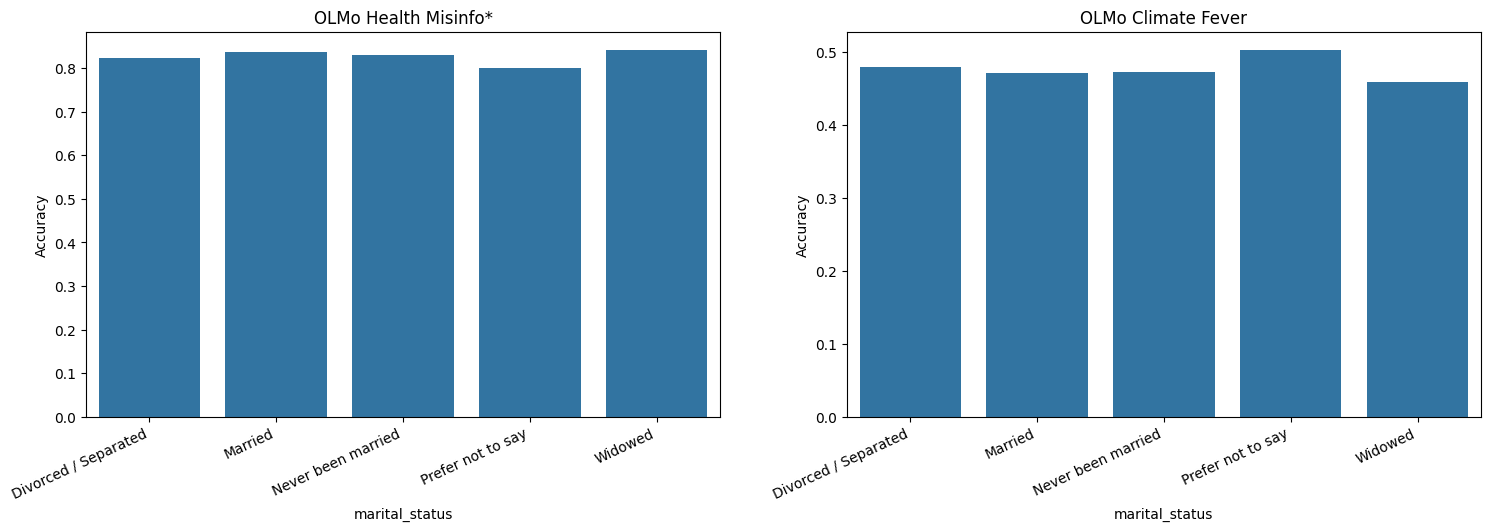

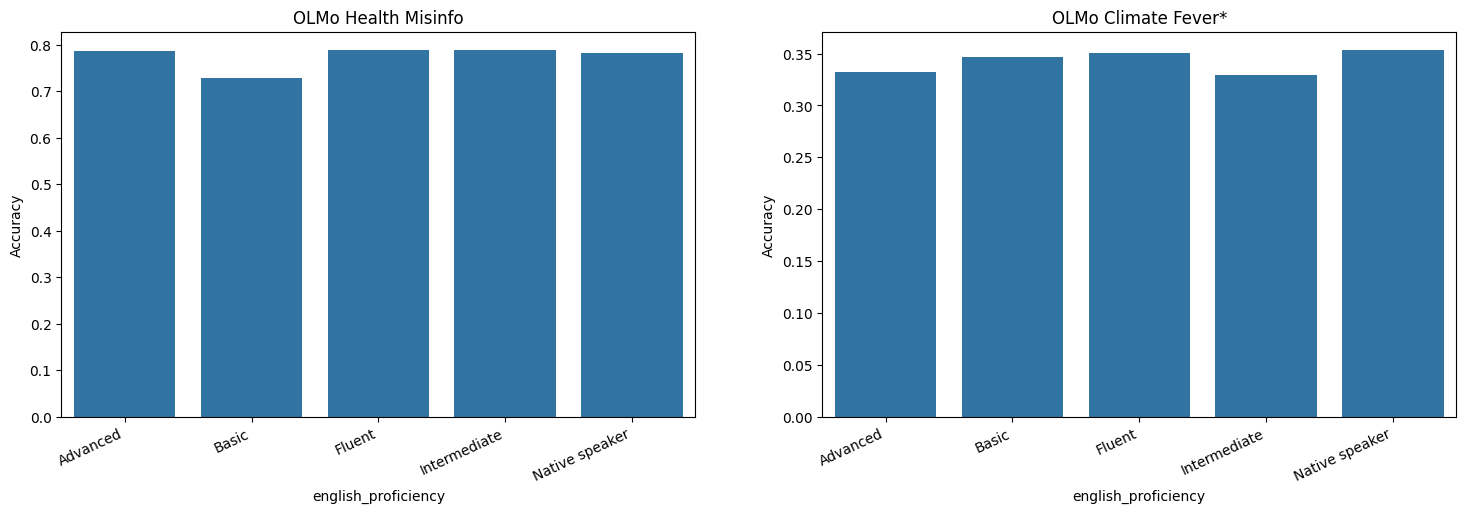

In [68]:
for demographic in demographics:
    fig, axes = plt.subplots(1, len(dfs), sharex=False,figsize=(18, 5))
    for i, model in enumerate(dfs):
        df = dfs[model][dfs[model]["question"].isin(diff_questions[model][demographic])].groupby([demographic, "type"])[["score"]].mean().reset_index()
        sns.barplot(
            data=df[df["type"]=="answer_correct"],
            x=demographic,
            y="score",
            ax=axes[i],
        )
        axes[i].set_ylabel("Accuracy")
        title = model
        if diff_accuracy[model][demographic] == True:
            title += "*"
        axes[i].set_title(title)
        axes[i].set_xticks(axes[i].get_xticks(), axes[i].get_xticklabels(), rotation=25, ha='right')
    plt.show()

In [69]:
def prepare_df(results):
    df = pd.DataFrame(results)
    df = df.T
    df = df.stack()
    df = df.reset_index()
    df = df.rename(columns={"level_0": "demographic", "level_1": "layer"})
    df = pd.concat([df.drop([0], axis=1), df[0].apply(pd.Series)], axis=1)
    f1_weighted = (
        pd.DataFrame(df["f1_weighted"].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "f1_weighted"})
    )
    f1_micro = (
        pd.DataFrame(df["f1_micro"].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "f1_micro"})
    )
    f1_macro = (
        pd.DataFrame(df["f1_macro"].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "f1_macro"})
    )
    acc_balanced = (
        pd.DataFrame(df["balanced_accuracy"].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "balanced_accuracy"})
    )
    #acc["acc"] = acc["acc"].mul(100)
    df = pd.merge(df, f1_weighted, left_index=True, right_on=["level_0"]).drop(
        columns=["f1_weighted_x"]
    )
    df = pd.merge(df, f1_micro, on=["level_0" ,"cv"]).drop(columns=["f1_micro_x"])
    df = pd.merge(df, f1_macro, on=["level_0" ,"cv"]).drop(columns=["f1_macro_x"])
    df = pd.merge(df, acc_balanced, on=["level_0", "cv"]).drop(columns=["balanced_accuracy_x", "level_0"]).rename(columns={"f1_weighted_y": "f1_weighted", "f1_micro_y": "f1_micro", "f1_macro_y": "f1_macro", "balanced_accuracy_y": "balanced_accuracy"})
    return df

In [72]:
with open("results/OLMo-2-1124-7B-Instruct_probe_results_mean.pkl", "rb") as infile:
    olmo_probe_mean = pickle.load(infile)

# with open("results/OLMo-2-1124-7B-Instruct_probe_results_last.pkl", "rb") as infile:
#     olmo_probe_last = pickle.load(infile)

with open("results/OLMo-2-1124-7B-DPO_probe_results_mean.pkl", "rb") as infile:
    olmo_dpo = pickle.load(infile)

with open("results/OLMo-2-1124-7B_probe_results_mean.pkl", "rb") as infile:
    olmo_base = pickle.load(infile)

with open("results/OLMo-2-1124-7B-SFT_probe_results_mean.pkl", "rb") as infile:
    olmo_sft = pickle.load(infile)

In [73]:
model_results = {
    "OLMo Instruct": olmo_probe_mean,
    #"OLMo last": olmo_probe_last,
    "OLMo DPO": olmo_dpo,
    "OLMo Base": olmo_base,
    "OLMo SFT": olmo_sft,
}
for model in model_results:
    results = model_results[model]
    df = prepare_df(results)
    model_results[model] = df

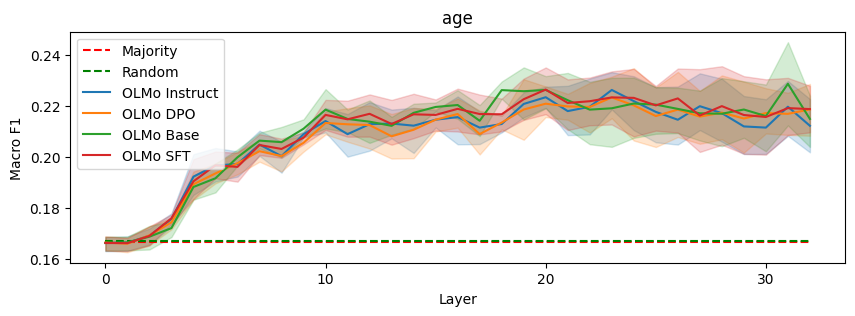

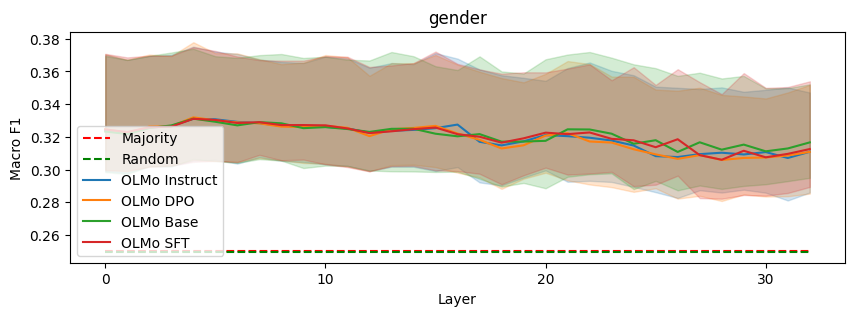

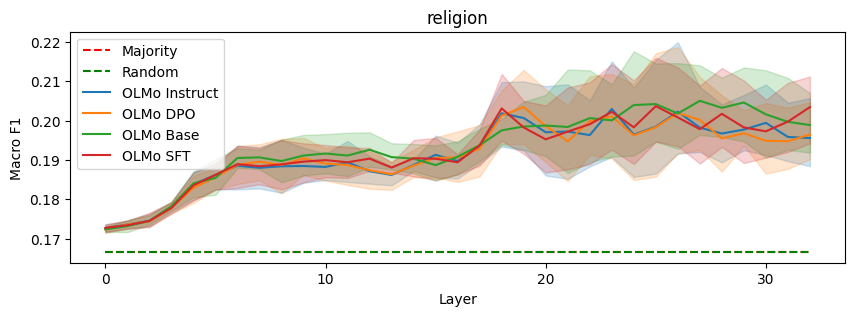

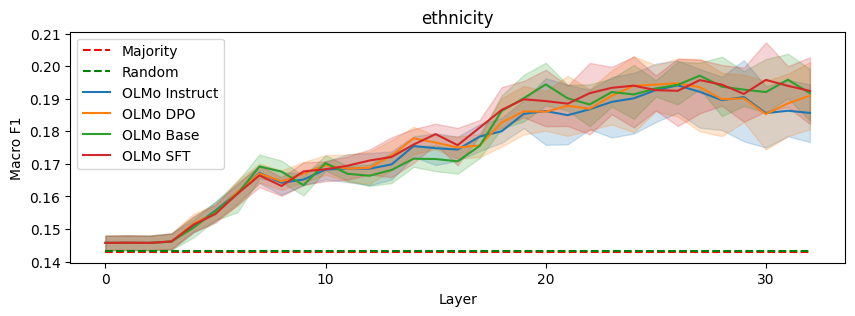

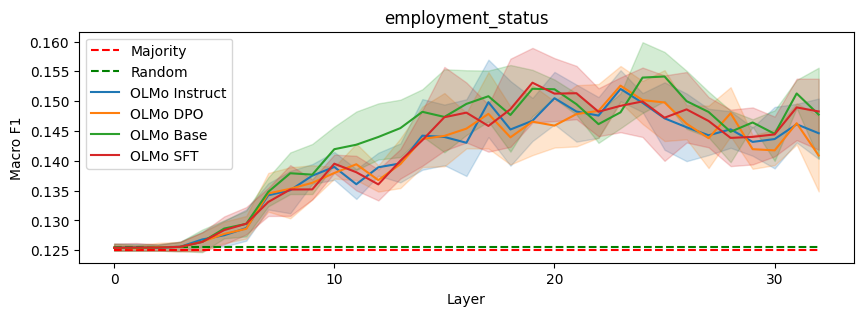

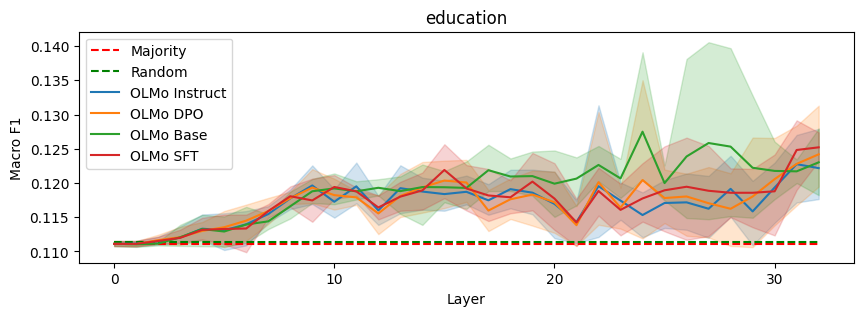

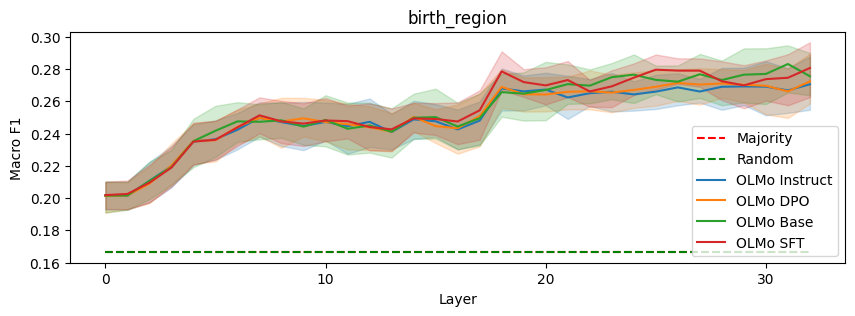

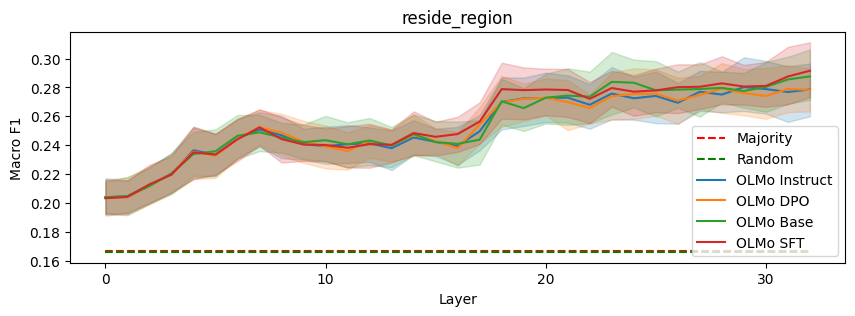

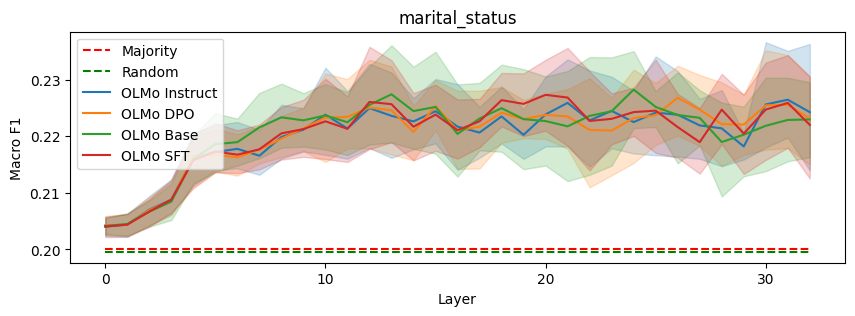

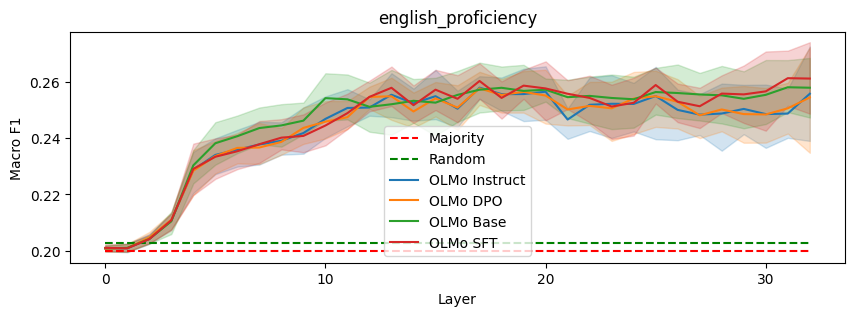

In [92]:
#plt.rcParams.update({"font.size": 30})

#metrics = {"f1_weighted": "Weighted F1", "f1_macro": "Macro F1", "balanced_accuracy": "Balanced accuracy", "f1_micro": "Micro F1"}

metric = "balanced_accuracy"

for demographic in demographics:
    fig, axes = plt.subplots(figsize=(10,3))
    axes.plot([0,32],[baselines[demographic][f"majority_{metric}"],baselines[demographic][f"majority_{metric}"]], color='r', linestyle='--', label="Majority")
    axes.plot([0,32],[baselines[demographic][f"random_{metric}"],baselines[demographic][f"random_{metric}"]], color='g', linestyle='--', label="Random")
    for i, model in enumerate(model_results):
        df = model_results[model]
        sns.lineplot(
            data=df[df["demographic"] == demographic],
            x="layer",
            y=metric,
            label=model,
            ax=axes,
        )
        axes.xaxis.set_major_locator(ticker.MultipleLocator(10))
        axes.set_xlabel("Layer")
        axes.set_title(demographic)
        axes.set_ylabel("Macro F1")
    plt.legend(loc="best")
    plt.show()